# Import packages & functions

In [ ]:
!git clone https://github.com/MedARC-AI/CLIBP.git

Cloning into 'CLIBP'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 39 (delta 15), reused 25 (delta 7), pack-reused 0
Receiving objects: 100% (39/39), 225.72 KiB | 7.05 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
%cd CLIBP/src

/content/CLIBP/src


In [ ]:
%pwd

'/content/CLIBP/src'

In [ ]:
# Import packages and setup gpu configuration.
# This code block shouldnt need to be adjusted!
import os
import sys
import json
import yaml
import numpy as np
import copy
import math
import time
import random
import matplotlib.pyplot as plt
import h5py

import torch
import torch.nn as nn
from torchvision import transforms
import utils

# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True # fixes Conv3D if used

### Multi-GPU config ###
device_count = torch.cuda.device_count()
print(f"Number of available CUDA devices: {device_count}")

local_rank = os.getenv('LOCAL_RANK')
local_rank = 0 if local_rank is None else int(local_rank)
print(f"LOCAL RANK={local_rank}")

num_devices = os.getenv('NUM_GPUS')
num_devices = 1 if num_devices is None else int(num_devices)
print(f"NUM GPUS={num_devices}")
distributed = True if num_devices>1 else False
if distributed: assert device_count==num_devices

node = os.getenv('SLURM_NODEID')
node = 0 if node is None else int(node)
print(f"NODE={node}")

global_rank = os.getenv('RANK')
global_rank = 0 if global_rank is None else int(global_rank)
print(f"GLOBAL RANK={global_rank}")

world_size = os.getenv('WORLD_SIZE')
world_size = 1 if world_size is None else int(world_size)
print(f"WORLD_SIZE={world_size}")

if utils.is_interactive():
    # Following allows you to change functions in utils.py and
    # have this notebook automatically update with your revisions
    %load_ext autoreload
    %autoreload 2
    from tqdm.notebook import tqdm
else:
    from tqdm import tqdm

# Load parameters from yaml config
config = yaml.load(open('config.yaml', 'r'), Loader=yaml.FullLoader)

# create global variables from the config
print("\n__CONFIG__")
for attribute_name in config.keys():
    print(f"{attribute_name} = {config[attribute_name]}")
    globals()[attribute_name] = config[f'{attribute_name}']
print("\n")

data_type = torch.float32 # change depending on your mixed_precision
global_batch_size = batch_size * world_size
device = torch.device('cuda')
print("device =", device, "distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)

# seed all random functions
utils.seed_everything(seed + global_rank)

Number of available CUDA devices: 1
LOCAL RANK=0
NUM GPUS=1
NODE=0
GLOBAL RANK=0
WORLD_SIZE=1

__CONFIG__
model_name = usebrainTrue
data_path = /weka/proj-medarc/shared/mindeyev2_dataset
batch_size = 128
wandb_log = True
ckpt_interval = 10
ckpt_saving = False
seed = 0
max_lr = 3e-05
num_epochs = 25
use_brain = True
temperature = 0.006


device = cuda distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


# Prep data, models, and dataloaders

### Load all voxels for a given NSD subject

In [ ]:
import h5py
import numpy as np
import torch
from huggingface_hub import hf_hub_download

# Set the repository ID
repo_id = "pscotti/mindeyev2"

# Download files
betas_file = hf_hub_download(repo_id=repo_id, filename="betas_all_subj01_fp32_renorm.hdf5", repo_type="dataset")
images_file = hf_hub_download(repo_id=repo_id, filename="coco_images_224_float16.hdf5", repo_type="dataset")
indices_file = hf_hub_download(repo_id=repo_id, filename="COCO_73k_subj_indices.hdf5", repo_type="dataset")
shared1000 = np.load(hf_hub_download(repo_id=repo_id, filename="shared1000.npy", repo_type="dataset"))
annots = np.load(hf_hub_download(repo_id="pscotti/naturalscenesdataset", filename="COCO_73k_annots_curated.npy", repo_type="dataset"))


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


betas_all_subj01_fp32_renorm.hdf5:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

coco_images_224_float16.hdf5:   0%|          | 0.00/22.0G [00:00<?, ?B/s]

COCO_73k_subj_indices.hdf5:   0%|          | 0.00/629k [00:00<?, ?B/s]

shared1000.npy:   0%|          | 0.00/73.1k [00:00<?, ?B/s]

COCO_73k_annots_curated.npy:   0%|          | 0.00/365M [00:00<?, ?B/s]

In [ ]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class MemoryEfficientDataset(Dataset):
    def __init__(self, images_file, voxels_file, indices, is_shared, annots):
        self.images_file = images_file
        self.voxels_file = voxels_file
        self.indices = indices
        self.is_shared = is_shared
        self.annots = annots

        # Check the actual size of the datasets
        with h5py.File(self.images_file, 'r') as f:
            self.images_size = f['images'].shape[0]
        with h5py.File(self.voxels_file, 'r') as f:
            self.voxels_size = f['betas'].shape[0]

        # Filter indices that are within bounds
        self.valid_indices = [idx for idx in self.indices if idx < min(self.images_size, self.voxels_size)]
        print(f"Filtered {len(self.indices) - len(self.valid_indices)} invalid indices")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]

        with h5py.File(self.images_file, 'r') as f:
            image = torch.tensor(f['images'][real_idx]).float()
        with h5py.File(self.voxels_file, 'r') as f:
            voxel = torch.tensor(f['betas'][real_idx]).float()
        return image, voxel, real_idx

# Load necessary data
with h5py.File(indices_file, 'r') as f:
    data = {key: f[key][()] for key in f.keys()}

image_indices = data["subj01"]
is_shared = shared1000[image_indices]

image_indices_train = image_indices[~is_shared]
image_indices_test = image_indices[is_shared]

print("image_indices_train range:", image_indices_train.min(), "-", image_indices_train.max())
print("image_indices_test range:", image_indices_test.min(), "-", image_indices_test.max())

# Create datasets
train_dataset = MemoryEfficientDataset(images_file, betas_file, image_indices_train, ~is_shared, annots)
test_dataset = MemoryEfficientDataset(images_file, betas_file, image_indices_test, is_shared, annots)

print("Images dataset size:", train_dataset.images_size)
print("Voxels dataset size:", train_dataset.voxels_size)
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

# Create data loaders
batch_size = 32  # Adjust as needed
train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

num_samples_per_epoch = len(train_dl.dataset)
print("num_samples_per_epoch", num_samples_per_epoch)
num_iterations_per_epoch = len(train_dl)
print("num_iterations_per_epoch", num_iterations_per_epoch)

# Example of how to use the data loader
for batch_images, batch_voxels, batch_indices in train_dl:
    print("Batch shapes:", batch_images.shape, batch_voxels.shape)
    print("Batch indices:", batch_indices)
    break  # Just print the first batch and break

# If you need to check annotations
sample_image, sample_voxel, sample_index = train_dataset[0]
print("Sample image shape:", sample_image.shape)
print("Sample voxel shape:", sample_voxel.shape)
print("Sample index:", sample_index)
print("Sample annotation:", utils.get_annotations(annots[sample_index:sample_index+1], random=False))

image_indices_train range: 13 - 72999
image_indices_test range: 2950 - 72948
Filtered 16074 invalid indices
Filtered 1797 invalid indices
Images dataset size: 73000
Voxels dataset size: 30000
Number of training samples: 10926
Number of test samples: 1203
num_samples_per_epoch 10926
num_iterations_per_epoch 342
Batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32, 15724])
Batch indices: tensor([10269, 22430, 18056, 23184,  4201, 13857, 19301, 25596, 15068,  1159,
        23865,  6697,  5185, 10115, 18427, 13945,  1368, 17602, 29916, 20287,
        11116,  6791,  8890, 16180, 24007, 13708, 27993, 11493, 24127, 11133,
        17386, 24929])
Sample image shape: torch.Size([3, 224, 224])
Sample voxel shape: torch.Size([15724])
Sample index: 828
Sample annotation: A man on a surfboard, who is riding a wave.


## Create/load models

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-9lrvs5ql
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-9lrvs5ql
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using c

In [ ]:
class BaseModule(nn.Module):
    def __init__(self):
        super(BaseModule, self).__init__()
    def forward(self, x):
        return x
model = BaseModule()
model

BaseModule()

In [ ]:
import clip
clip_model, _ = clip.load("ViT-L/14", device=device)
preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])
def clip_img_embedder(image):
    preproc_img = preprocess(image)
    return clip_model.encode_image(preproc_img)
clip_emb_dim = 768

# you can do clip_img_embedder(image) to get the ground truth CLIP image embeddings
# you can do clip.tokenize(annot) to get the ground truth CLIP image caption embeddings

100%|███████████████████████████████████████| 890M/890M [00:12<00:00, 72.6MiB/s]


In [ ]:
class SimpleViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=768, dim=768, depth=12, heads=12, mlp_dim=3072, channels=3, dropout=0.1, emb_dropout=0.1):
        super(SimpleViT, self).__init__()

        assert image_size % patch_size == 0, 'Image dimensions must be divisible by the patch size.'
        num_patches = (image_size // patch_size) ** 2
        patch_dim = channels * patch_size ** 2

        self.patch_size = patch_size

        self.to_patch_embedding = nn.Conv2d(channels, dim, kernel_size=patch_size, stride=patch_size)

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )

        self.to_cls_token = nn.Identity()
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)  # (batch_size, dim, num_patches ** 0.5, num_patches ** 0.5)
        x = x.flatten(2)  # (batch_size, dim, num_patches)
        x = x.transpose(1, 2)  # (batch_size, num_patches, dim)
        b, n, _ = x.shape

        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (batch_size, num_patches + 1, dim)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = x.transpose(0, 1)  # Transformer expects (seq_len, batch_size, dim)
        x = self.transformer(x)
        x = x[0]  # Take the CLS token output
        return self.mlp_head(x)

model.image = SimpleViT()
utils.count_params(model.image)
utils.count_params(model)

# check model is working
b = preprocess(images_train[:2])
print(b.shape, model.image(b).shape)

param counts:
86,389,248 total
86,389,248 trainable
param counts:
86,389,248 total
86,389,248 trainable


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


NameError: name 'images_train' is not defined

In [ ]:
if use_brain:
    class RidgeRegression(torch.nn.Module):
        def __init__(self, input_sizes, out_features, final_out):
            super(RidgeRegression, self).__init__()
            self.out_features = out_features
            self.linears = torch.nn.ModuleList([
                    torch.nn.Linear(input_size, out_features) for input_size in input_sizes
                ])
            self.projector = nn.Sequential(
                nn.LayerNorm(out_features),
                nn.GELU(),
                nn.Linear(out_features, out_features),
                nn.LayerNorm(out_features),
                nn.GELU(),
                nn.Linear(out_features, final_out),
                nn.LayerNorm(final_out),
                nn.GELU(),
                nn.Linear(final_out, final_out)
            )
        def forward(self, x, subj_idx=0):
            out = self.linears[subj_idx](x)
            out = self.projector(out).squeeze(1)
            return out

    model.ridge = RidgeRegression([num_voxels], out_features=4096, final_out=clip_emb_dim)
    utils.count_params(model.ridge)
    utils.count_params(model)

    # test on subject 1 with fake data
    b = torch.randn((2,num_voxels))
    print(b.shape, model.ridge(b).shape)

NameError: name 'num_voxels' is not defined

In [ ]:
if use_brain:
    ckpt_path = "/weka/proj-fmri/paulscotti/MindEye2_git/train_logs/final_subj01_pretrained_40sess_24bs/last.pth"
    # downloadable from here: https://huggingface.co/datasets/pscotti/mindeyev2

    checkpoint = torch.load(ckpt_path, map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    model.load_state_dict(state_dict, strict=False)
    print("ckpt loaded!")

    # disable further training of the linears (only want to train the projector)
    model.ridge.linears.requires_grad_(False)

## Setup optimizer / lr / ckpt saving

In [ ]:
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']

opt_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 1e-2},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]

optimizer = torch.optim.AdamW(opt_grouped_parameters, lr=max_lr)

total_steps=int(np.floor(num_epochs*num_iterations_per_epoch))
print("total_steps", total_steps)
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=max_lr,
    total_steps=total_steps,
    final_div_factor=1000,
    last_epoch=-1, pct_start=2/num_epochs
)

outdir = os.path.abspath(f'../ckpts/{model_name}')

def save_ckpt(tag):
    ckpt_path = outdir+f'/{tag}.pth'
    os.makedirs(outdir,exist_ok=True)
    torch.save({
        'epoch': epoch,
        'model_state_dict': unwrapped_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'lr_scheduler': lr_scheduler.state_dict(),
        }, ckpt_path)
    print(f"\n---saved {outdir}/{tag} ckpt!---\n")

def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir):
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

print("\nDone with model preparations!")
num_params = utils.count_params(model)

total_steps 5275

Done with model preparations!
param counts:
171,335,168 total
106,925,568 trainable


# Weights and Biases

In [ ]:
if local_rank==0 and wandb_log: # only use main process for wandb logging
    import wandb
    wandb_project = 'CLIBP'
    print(f"wandb {wandb_project} run {model_name}")
    # need to configure wandb beforehand in terminal with "wandb init"!
    wandb_config = {
      "model_name": model_name,
      "global_batch_size": global_batch_size,
      "batch_size": batch_size,
      "num_epochs": num_epochs,
      "num_params": num_params,
      "max_lr": max_lr,
      "num_samples_per_epoch": num_samples_per_epoch,
      "ckpt_interval": ckpt_interval,
      "ckpt_saving": ckpt_saving,
      "seed": seed,
      "distributed": distributed,
      "num_devices": num_devices,
      "world_size": world_size,
    }
    print("wandb_config:\n",wandb_config)
    print("wandb_id:",model_name)
    wandb.init(
        id=model_name,
        project=wandb_project,
        name=model_name,
        config=wandb_config,
        resume="never",
    ) # would need to make modifications to training code to allow resume="allow"
else:
    wandb_log = False

wandb CLIBP run usebrainTrue_notpretrained
wandb_config:
 {'model_name': 'usebrainTrue_notpretrained', 'global_batch_size': 128, 'batch_size': 128, 'num_epochs': 25, 'num_params': 106925568, 'max_lr': 3e-05, 'num_samples_per_epoch': 27000, 'ckpt_interval': 10, 'ckpt_saving': False, 'seed': 0, 'distributed': False, 'num_devices': 1, 'world_size': 1}
wandb_id: usebrainTrue_notpretrained


wandb: Currently logged in as: paul-scotti. Use `wandb login --relogin` to force relogin


# Main

In [ ]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
model.to(device)

BaseModule(
  (image): SimpleViT(
    (to_patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (dropout): Dropout(p=0.1, inplace=False)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-11): 12 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (linear1): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=3072, out_features=768, bias=True)
          (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (to_cls_token): Identity()
    (mlp_head): Sequential(
      (0): LayerNorm((768,), eps=1e-0

In [ ]:
print(f"{model_name} starting with epoch {epoch} / {num_epochs}")
progress_bar = tqdm(range(epoch,num_epochs), ncols=1000, disable=(local_rank!=0))
mse = nn.MSELoss()
crossentropy = nn.CrossEntropyLoss()

for epoch in progress_bar:
    ret_percent_correct, test_ret_percent_correct = 0., 0.
    txt_2_img_percent_correct, test_txt_2_img_percent_correct = 0., 0.
    img_2_txt_percent_correct, test_img_2_txt_percent_correct = 0., 0.

    for train_i, data in enumerate(train_dl):
        model.train()
        optimizer.zero_grad()

        image, voxel, idx = data
        image = image.to(device)
        voxel = voxel.to(device)
        annot = utils.get_annotations(annots[idx],random=False)
        annot = clip.tokenize(annot).to(device)

        clip_image = model.image(image)
        clip_text = clip_model.encode_text(annot).to(clip_image.dtype)
        if use_brain:
            clip_brain = model.ridge(voxel)

        labels = torch.arange(len(clip_image)).to(device)

        clip_image = nn.functional.normalize(clip_image, dim=-1)
        clip_text = nn.functional.normalize(clip_text, dim=-1)
        if use_brain:
            clip_brain = nn.functional.normalize(clip_brain, dim=-1)

        logits_image_text = (clip_image @ clip_text.T) / temperature
        loss_image_text = nn.functional.cross_entropy(logits_image_text, labels)

        if use_brain:
            logits_image_brain = (clip_image @ clip_brain.T) / temperature
            loss_image_brain = nn.functional.cross_entropy(logits_image_brain, labels)

            logits_text_brain = (clip_text @ clip_brain.T) / temperature
            loss_text_brain = nn.functional.cross_entropy(logits_text_brain, labels)

            loss = (loss_image_text + loss_image_brain + loss_text_brain) / 3
        else:
            loss = loss_image_text

        ret1 = utils.topk(utils.batchwise_cosine_similarity(clip_image, clip_text), labels, k=1).item()
        ret2 = utils.topk(utils.batchwise_cosine_similarity(clip_text, clip_image), labels, k=1).item()

        if use_brain:
            ret3 = utils.topk(utils.batchwise_cosine_similarity(clip_image, clip_brain), labels, k=1).item()
            ret4 = utils.topk(utils.batchwise_cosine_similarity(clip_brain, clip_image), labels, k=1).item()

            ret5 = utils.topk(utils.batchwise_cosine_similarity(clip_text, clip_brain), labels, k=1).item()
            ret6 = utils.topk(utils.batchwise_cosine_similarity(clip_brain, clip_text), labels, k=1).item()

        if use_brain:
            ret_percent_correct += (ret1 + ret2 + ret3 + ret4 + ret5 + ret6) / 6
        else:
            ret_percent_correct += (ret1 + ret2) / 2

        img_2_txt_percent_correct += ret1
        txt_2_img_percent_correct += ret2

        utils.check_loss(loss)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]['lr'])

        lr_scheduler.step()

    model.eval()
    with torch.no_grad():
        for test_i, test_data in enumerate(test_dl):
            image, voxel, idx = test_data
            image = image.to(device)
            voxel = voxel.to(device)
            annot = utils.get_annotations(annots[idx],random=False)
            annot = clip.tokenize(annot).to(device)

            clip_image = model.image(image)
            clip_text = clip_model.encode_text(annot).to(clip_image.dtype)
            if use_brain:
                clip_brain = model.ridge(voxel)

            labels = torch.arange(len(clip_image)).to(device)

            clip_image = nn.functional.normalize(clip_image, dim=-1)
            clip_text = nn.functional.normalize(clip_text, dim=-1)
            if use_brain:
                clip_brain = nn.functional.normalize(clip_brain, dim=-1)

            logits_image_text = (clip_image @ clip_text.T) / temperature
            loss_image_text = nn.functional.cross_entropy(logits_image_text, labels)

            if use_brain:
                logits_image_brain = (clip_image @ clip_brain.T) / temperature
                loss_image_brain = nn.functional.cross_entropy(logits_image_brain, labels)

                logits_text_brain = (clip_text @ clip_brain.T) / temperature
                loss_text_brain = nn.functional.cross_entropy(logits_text_brain, labels)

                loss = (loss_image_text + loss_image_brain + loss_text_brain) / 3
            else:
                loss = loss_image_text

            ret1 = utils.topk(utils.batchwise_cosine_similarity(clip_image, clip_text), labels, k=1).item()
            ret2 = utils.topk(utils.batchwise_cosine_similarity(clip_text, clip_image), labels, k=1).item()

            if use_brain:
                ret3 = utils.topk(utils.batchwise_cosine_similarity(clip_image, clip_brain), labels, k=1).item()
                ret4 = utils.topk(utils.batchwise_cosine_similarity(clip_brain, clip_image), labels, k=1).item()

                ret5 = utils.topk(utils.batchwise_cosine_similarity(clip_text, clip_brain), labels, k=1).item()
                ret6 = utils.topk(utils.batchwise_cosine_similarity(clip_brain, clip_text), labels, k=1).item()

            if use_brain:
                test_ret_percent_correct += (ret1 + ret2 + ret3 + ret4 + ret5 + ret6) / 6
            else:
                test_ret_percent_correct += (ret1 + ret2) / 2

            test_img_2_txt_percent_correct += ret1
            test_txt_2_img_percent_correct += ret2

            utils.check_loss(loss)
            test_losses.append(loss.item())

        logs = {"train/loss": np.mean(losses[-(train_i+1):]),
            "test/loss": np.mean(test_losses[-(test_i+1):]),
            "train/lr": lrs[-1],
            "train/num_steps": len(losses),
            "test/num_steps": len(test_losses),
            "train/ret_pct_correct": ret_percent_correct / (train_i + 1),
            "test/test_ret_pct_correct": test_ret_percent_correct / (test_i + 1),
            "train/img_2_txt_percent_correct": img_2_txt_percent_correct / (train_i + 1),
            "test/img_2_txt_percent_correct": test_img_2_txt_percent_correct / (test_i + 1),
            "train/txt_2_img_percent_correct": txt_2_img_percent_correct / (train_i + 1),
            "test/txt_2_img_percent_correct": test_txt_2_img_percent_correct / (test_i + 1),
            }
        progress_bar.set_postfix(**logs)

        if wandb_log: wandb.log(logs)

        # Save model checkpoint and reconstruct
        if (ckpt_saving) and (epoch % ckpt_interval == 0):
            save_ckpt(f'last')

        # wait for other GPUs to catch up if needed
        if distributed:
            dist.barrier()

print("\n===Finished!===\n")
if ckpt_saving: save_ckpt(f'last')

usebrainTrue_notpretrained starting with epoch 0 / 25


  0%|                                                                                                         …


===Finished!===



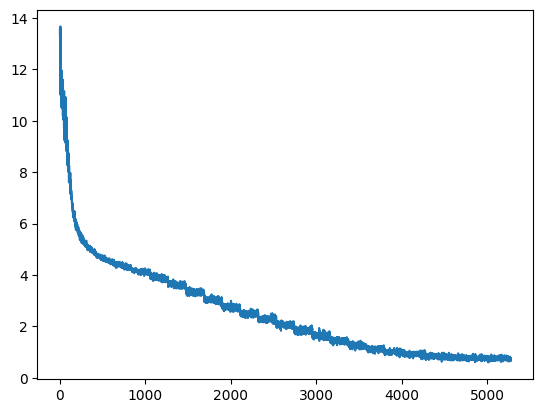

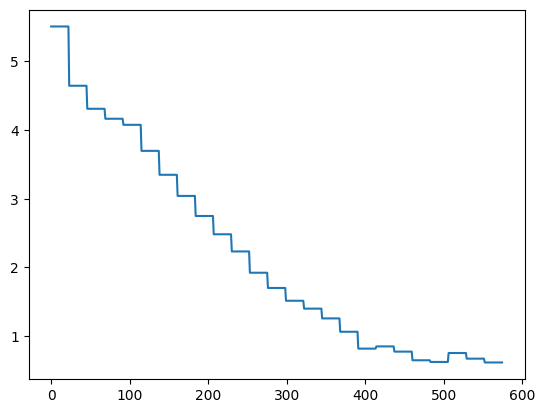

In [ ]:
plt.plot(losses)
plt.show()
plt.plot(test_losses)
plt.show()